# CSE2530 Computational Intelligence
## Assignment 1: Ant Colony Optimization and Genetic Algorithms



_Fill in your group number **from Brightspace**, names, and student numbers._
    
|    Group   |           40          |
|------------|----------------------|
| Jacek Obiała  |        6185665       |
| Michał Szelejewski  |        6219128       |
| Marcin Łysikowski  |        6182771       |
| Adam Porat  |        6260438       |

#### Imports

In [163]:
"""
You may only use numpy to implement your algorithms
You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.
Put all of your imports in this code block.
"""
import numpy as np
import random
import sys
import time
import matplotlib.pyplot as plt

"""
The following classes are fully implemented in their own files and you should not change them.
Nonetheless, we encourage you to check how they work; this will help you get started.
"""
from Coordinate import Coordinate
from Direction import Direction
from PathSpecification import PathSpecification
from Route import Route
from SurroundingPheromone import SurroundingPheromone
from TSPData import TSPData

## Part 1: The Travelling Robot Problem
### 1.1 Problem Analysis
#### Question 1:

Usually it is defined as a 2d matrix of costs[i][j] where costs at [i][j] gives us a cost moving from city i to city j. Our goal is to visit every city exactly once and come back to the starting city in the minimum cost (distance). 

reference: https://www.geeksforgeeks.org/dsa/travelling-salesman-problem-using-dynamic-programming/

#### Question 2

1. Our nodes do not create a complete graph as we do not have direct connections to all nodes
2. Nodes can be connected through multiple paths so they are not necessarily singularly connected
3. We do not know the relative distances from each node 

#### Question 3

Because TSP is np-hard we cannot solve it using normal algorithms in sensible time. The CI aproach can give us a really good approximate of the best result in a sensible time in comparison to brute-force approach. We have to give up precision for speed. We use some randomness each iteration using CI to escape local minima to make sure we do not miss a better solution. Also saving only the best routes each iteration gives us already a better start for another iteration (the fittest survive).

### 1.2 Genetic Algorithm

In [164]:
optimal_tsp = TSPData.read_from_file("./../data/optimal_tsp")

# TSP problem solver using genetic algorithms.
class GeneticAlgorithm:

    """
    Constructs a new 'genetic algorithm' object.
    @param generations: the amount of generations.
    @param pop_size: the population size.
    """
    def __init__(self, generations, pop_size):
        self.generations = generations
        self.pop_size = pop_size
        self.population = []
        self.avg_fitness_per_gen = []
        self.top_fitness_per_gen = []
    """
    This method should solve the TSP.
    @param tsp_data: the data describing the problem.
    @return the optimized product sequence.
    """
    def solve_tsp(self, tsp_data):
        # initializing the population with random chromosomes
        n_prod = len(tsp_data.get_start_distances())
        for i in range(self.pop_size):
            ordered = range(n_prod)
            randomized = random.sample(ordered, n_prod)
            self.population.append(Chromosome(randomized))
        #containers for plotting
        top_fitness_in_gen = 0
        # main evolution loop
        for i in range(self.generations):
            new_population = []

            # count the total fitness in the current population
            total_fitness = 0
            for chromosome in self.population:
                chrom_fit = chromosome.calc_fitness(tsp_data)
                if(chrom_fit > top_fitness_in_gen):
                    top_fitness_in_gen = chrom_fit
                total_fitness += chrom_fit
            
            # repeatedly select two parents for crossover
            for j in range(int(self.pop_size/2)):
                # parent 1
                k = total_fitness*random.random()
                acc = 0
                for chromosome in self.population:
                    acc += chromosome.fitness
                    if acc > k:
                        p1 = chromosome
                        break
                
                # parent 2
                k = total_fitness*random.random()
                acc = 0
                for chromosome in self.population:
                    acc += chromosome.fitness
                    if acc > k:
                        p2 = chromosome
                        break

                c1, c2 = self.crossover(p1, p2)

                self.mutation(c1)
                self.mutation(c2)

                new_population.append(c1)
                new_population.append(c2)

            self.avg_fitness_per_gen.append(total_fitness/self.pop_size)
            self.top_fitness_per_gen.append(top_fitness_in_gen)

            self.population = new_population

        # find the individual with the best fitness among the finalpopulation
        top_fitness = 0
        for chromosome in self.population:
            fitness = chromosome.calc_fitness(tsp_data)
            if fitness > top_fitness:
                top_fitness = fitness
                self.best_chromosome = chromosome

        return self.best_chromosome.genes

    """
    Performs a crossover between two chromosomes with probability p (otherwise clones them).
    @param c1, c2: parent chromosomes.
    @param p: probability of crossover.
    @return two child chromosomes.
    """
    def crossover(self, c1, c2, p=0.7):
        g1 = c1.genes
        g2 = c2.genes

        k = random.random()
        if k > p:
            return Chromosome(g1), Chromosome(g2)
        
        k = random.randint(0, len(g1))

        g3 = g1[:k]
        for i in range(len(g2)):
            if g2[i] not in g3:
                g3.append(g2[i])
        
        g4 = g2[:k]
        for i in range(len(g1)):
            if g1[i] not in g4:
                g4.append(g1[i])

        return Chromosome(g3), Chromosome(g4)

    """
    Mutates a given chromosome with probability p for each gene.
    @param individual: the chromosome for mutation.
    @param p: probability of mutating a gene.
    @return the (un-)mutated chromosome.
    """
    def mutation(self, individual, p=0.007):
        genes = individual.genes
        
        for i in range(len(genes)):
            k = random.random()
            
            if k < p:
                k1 = i
                k2 = random.randint(0, len(genes)-1)
                
                temp = genes[k1]
                genes[k1] = genes[k2]
                genes[k2] = temp

        return individual
    
    def plot_fitness(self):
        plt.plot(self.avg_fitness_per_gen, label="average fitness")
        plt.plot(self.top_fitness_per_gen, label="best fitness")
        plt.title("Fitness per generation")
        plt.legend()
        plt.xlabel("generations")
        plt.ylabel("fitness")
        plt.show()
    
class Chromosome:
    """
    Constructs a new chromosome object and initializes it with a given list of genes.
    @param genes
    """
    def __init__(self, genes):
        self.genes = genes
    
    """
    Calculates the fitness of a chromosome.
    @param tsp_data: data for the maze on which the chromosome is being evaluated.
    @return fitness.
    """
    def calc_fitness(self, tsp_data):
        self.fitness = 1/self.calc_length(tsp_data)
        return self.fitness
    """
    Calculates the length of the path given by this chromosome.
    @param tsp_data: data for the maze on which the chromosome is being evaluated.
    @return length. 
    """
    def calc_length(self, tsp_data):
        tot_dist = 0
        dists = tsp_data.get_distances()
        tot_dist += tsp_data.get_start_distances()[self.genes[0]]
        for i in range(len(self.genes) - 1):
            tot_dist += dists[self.genes[i]][self.genes[i+1]]
        tot_dist += tsp_data.get_end_distances()[self.genes[len(self.genes) - 1]]
        return tot_dist
    

#### Question 4

In our implementation, each gene represents a node in the graph (or a product in the supermarket). We encode them in the chromosome as a list of integers, where each integer represents a node/gene and the order in which they appear represents the order they are visited. 

#### Question 5

We will use as a fitness function $\dfrac{1}{distance}$ as we need a value that is inversely proportional to the distance. As lower distance means higher fitness (better results)

#### Question 6

We are going to use Roulette Wheel Selection. Using the fitness ratio formula $r(x_i)= \dfrac{f(x_i)}{\sum_j f(x_j)}\cdot 100 \%$. We will then randomly take a parent based on the fitness ratio (the more fitness ratio a parent has, the greater the probability it will be chosen)

#### Question 7

We implemented two genetic operations. The first one is genetic crossover. Here, two selected parents create an offspring by swapping their chromosomes after a given crossover point. The first part of the offspring is the first part of one of the parents until the crossover point and the second half are the remaining genes in the same order as they appear in the second parent. The purpose of this operation is to combine genes from parents that have a high fitness and hopefully find a combination that can maximize it even more. This emulates reproduction in biology.

The second genetic operation is mutation. Here, we pass an offspring and for each gene, it has a small chance of mutating that gene by swapping it with another gene. The purpose of this function is to allow for more exploration of the search space in the hopes of getting out of a potential local minima. Most mutations will probably lead to a less optimal solution with a lower fitness, but some mutations might find solutions that the current parents would never be able to find by genetic crossover. 

#### Question 8

As stated in the previous question, mutation is the mechanism that we use to get out of a local minima. It helps us look into other parts of the search space we couldn't normally reach using only genetic crossover in the hopes that those places can lead to even better minima. 

#### Question 9

Elitism is a process of selecting a small group of the best performing individuals from the population and pass them without mutation to the next generation (So we won't lose fittest individuals over populations through random mutations and crossovers).

We are not using elitism. However we will take some best performing individuals to the next generations by the probabilistic approach we take. Because we are using the Roulette Wheel Selection and have some percentage for crossover (for example 70\%) and some small chance for mutation. We automatically have more probability we choose the best performing parents and if there is no crossover (the remaining 30\%) and no mutation we will pass the same genes along to the next generation. In that way we have a probabilistic chance we actually will preserve best genes, so we do not need to explicitly take the best performing individuals and always pass them to the next generation (elitism approach).

#### Question 10

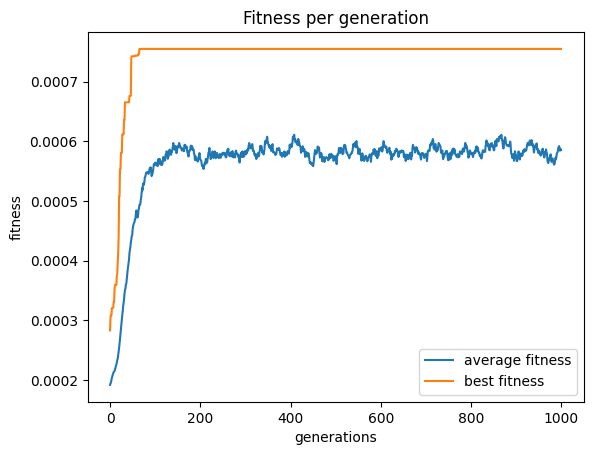

Length of found solution: 1325.


In [165]:
# Please keep your parameters for the Genetic Algorithm easily changeable here
population_size = 1000
generations = 1000
persist_file = "./../data/optimal_tsp"

# Setup optimization
tsp_data = TSPData.read_from_file(persist_file)
ga = GeneticAlgorithm(generations, population_size)

# Run optimzation and write to file
solution = ga.solve_tsp(tsp_data)
tsp_data.write_action_file(solution, "./../data/40_actions_TSP.txt")

ga.plot_fitness()
print(f"Length of found solution: {ga.best_chromosome.calc_length(tsp_data)}.")

After running the algorithm a few times, the length seems to never go below 1325 and it often stops improving around values below 1380, therefore we believe that 1325 is the length of optimal solution or at least very close to it.

## Part 2: Path Finding Through Ant Colony Optimization
### 2.2 Observing the Problem

#### Question 11

The purpose of ACO is finding (near) optimal paths through some weighted graph. It is therefore typically used for routing problems, but also scheduling and network design problems, as well as image processing and even protein folding. ACO is especially well-suited for very large problems with dynamically-changing costs.

#### Question 12

Sparse paths, so there are a lot of paths that are going to nowhere or are looping, then we would need a lot of ants (hence computing power) to even find the finish line. 
Also flat terrain which makes the exploration more random as there are no direct walls to discriminate some movements (the ants are free to move anywhere).

#### Question 13

$Δτ^k = Q \cdot \frac{1}{L ^k}$ 

, where $Δτ^k$ is the amount of pheromone left on a path, Q is a constant, $L^k$ is the length of the path

Ants drop pheromone in the maze in order to allow the next ants to follow the shortest path that will have the most pheromone. This is because the shortest paths will be left with the most pheromone, as the amount left is inversely proportional to the length of the path.

#### Question 14

$τ_{ij} = (1 - 	ρ) \cdot τ_{ij}  + \sum_{k=1}^{m} Δτ^k_{ij}$ 

, where $Δτ_{ij}$ is the amount of pheromone currently on path $ij$, $ρ$ is an evaporation constant, $\sum_{k=1}^{m} Δτ^k_{ij}$ is the sum of all the pheromone released on that link by all the ants that passed by it this round 

The pheromone evaporates to make previous decisions influence exploration less. Because of this the colony would not converge to a single path early and should explore many paths because the pheromone left from single bad choices will evaporate.

### 2.3 Implementing the Ant Algorithm

In [166]:
import matplotlib.pyplot as plt
import numpy as np

#Generated by Chat GPT
def draw_maze_matplotlib(walls, ant_pos, start, end):
    plt.clf()

    # transpose: walls[column][row] -> grid[row][column]
    grid = np.array(walls).T

    # show grid (row 0 at top, rows grow downward)
    plt.imshow(grid, origin="upper", interpolation="nearest")

    # scatter uses (x, y) = (column, row)
    plt.scatter([ant_pos.x], [ant_pos.y])
    plt.scatter([start.x], [start.y])
    plt.scatter([end.x], [end.y])

    plt.pause(0.1)

In [167]:
# Class that represents the basic Ant functionality
class StandardAnt:

    """
    Constructor of a StandardAnt taking a Maze and PathSpecification
    @param maze: the Maze where the ant will try to find a route
    @param path_specification: the PathSpecification consisting of a start and an end coordinate
    """
    def __init__(self, maze, path_specification):
        self.maze = maze
        self.start = path_specification.get_start()
        self.end = path_specification.get_end()
        self.current_position = self.start
        self.rand = random

    """
    Method that performs a single complete run through the maze by the ant
    @return the route found by the ant
    """
    def find_route(self):
        route = Route(self.start)
        while self.end != self.current_position:
            phn, phs, phe, phw = self.maze.get_surrounding_pheromone(self.current_position)
            total = phn + phs + phw + phe
            n = phn / total
            s = phs / total
            w = phw / total
            e = phe / total
            dir = [0, 1, 2, 3]

            pro = [e, n, w, s]
            
            choice = self.rand.choices(dir, weights=pro, k=1)[0] #choose a path with weighted probabilities
            
            if choice == 2:
                route.add(Direction.west)
                self.current_position = self.current_position.subtract_direction(Direction.east)
            elif choice == 3:
                route.add(Direction.south)
                self.current_position = self.current_position.subtract_direction(Direction.north)
            elif choice == 0:
                route.add(Direction.east)
                self.current_position = self.current_position.subtract_direction(Direction.west)
            elif choice == 1:
                route.add(Direction.north)
                self.current_position = self.current_position.subtract_direction(Direction.south)
            else:
                1/0 # else throw an error
            #self.counter = self.counter + 1
            #if(self.counter % 1000 == 0):
            #    draw_maze_matplotlib(
            #        self.maze.walls,
            #        self.current_position,
            #        self.start,
            #        self.end
            #    )
        return route


        


In [176]:
# Class that holds all of the maze data.
# This includes the pheromones, the open and blocked tiles in the system,
# and the starting and end coordinates for the ants.
class Maze:

    """
    Constructor of a Maze
    @param walls: array of ints representing the accessible (1) and inaccessible (0) tiles
    @param width: the width (horizontal dimension) of the Maze
    @param length: the length (vertical dimension) of the Maze
    """
    def __init__(self, walls, width, length):
        self.walls = walls
        self.length = length
        self.width = width
        self.start = None
        self.end = None
        self.initialize_pheromones()

    """
    Initialize pheromones on all tiles of the Maze
    """
    def initialize_pheromones(self):
        height = len(self.walls[0])
        width = len(self.walls)
        self.width = width
        avg_probability = 1
        self.pheromones = [None] * (width * height)
        for i in range(height * width):
            col = i // height
            row = i % height
            # first find out positions of the neighbouring tiles, -1 if there are none
            pos_north = i - 1 if row > 0 else -1
            pos_east = i + height if col + 1 < width else -1
            pos_west = i - height if col > 0 else -1
            pos_south = i + 1 if row + 1 < height else -1


            # assign the corresponding probability to them
            north = avg_probability if(pos_north != -1 and self.walls[col][row - 1] == 1) else 0
            east = avg_probability if(pos_east != -1 and self.walls[col + 1][row] == 1) else 0
            west = avg_probability if(pos_west != -1 and self.walls[col - 1][row] == 1) else 0
            south = avg_probability if(pos_south != -1 and self.walls[col][row + 1] == 1) else 0
            self.pheromones[i] = SurroundingPheromone(north, east, south, west)


    """
    Reset the Maze for a new shortest path problem
    """
    def reset(self):
        self.initialize_pheromones()

    """
    Update the pheromones along a certain route according to a certain Q
    @param route: the route taken by an ant
    @param q: the normalization factor for the amount of dropped pheromone
    """
    def add_pheromone_route(self, route, q):
        positions = route.get_route()
        length = route.size()
        current = route.get_start()
        current = current.x * self.length + current.y
        
        for i in range(length):
            dir = positions[i]
            self.pheromones[current].total_surrounding_pheromone +=  q * 1 / length
            if dir == Direction.east:
                newVal = self.pheromones[current].east + q * 1 / length
                self.pheromones[current].east = newVal
                current = current + self.length
                self.pheromones[current].west = newVal
            elif dir == Direction.north:
                newVal = self.pheromones[current].north + q * 1 / length
                self.pheromones[current].north = newVal
                current = current - 1
                self.pheromones[current].south = newVal
            elif dir == Direction.west:
                newVal = self.pheromones[current].west + q * 1 / length
                self.pheromones[current].west = newVal
                current = current - self.length
                self.pheromones[current].east = newVal
            else:
                newVal = self.pheromones[current].south + q * 1 / length
                self.pheromones[current].south = newVal
                current = current + 1
                self.pheromones[current].north = newVal

            

    """
    Update pheromones for a list of routes
    @param routes: a list of routes taken by the ants
    @param q: the normalization factor for the amount of dropped pheromone
    """
    def add_pheromone_routes(self, routes, q):
        for r in routes:
            if(not(r is None)):
                self.add_pheromone_route(r, q)

    """
    Evaporate pheromone
    @param rho: the evaporation factor
    """
    def evaporate(self, rho):
        for i in range(len(self.walls)):
            # first find out positions of the neighbouring tiles, -1 if there are none
            pos_north = i - self.width if i - self.width >= 0 else -1
            pos_east = i + 1 if (i % self.width) + 1 <= self.width else -1
            pos_west = i - 1 if (i % self.width) - 1 >= 0 else -1
            pos_south = i + self.width if i + self.width <= len(self.walls) else -1
            # assign the corresponding probability to them
            if pos_north != -1: 
                self.pheromones[i].north = (1 - rho) * self.pheromones[i].north 
            if pos_east != -1: 
                self.pheromones[i].east = (1 - rho) *  self.pheromones[i].east
            if pos_west != -1: 
                self.pheromones[i].west = (1 - rho) *  self.pheromones[i].west 
            if pos_south != -1: 
                self.pheromones[i].south = (1 - rho) * self.pheromones[i].south 
            

    """
    Getter for the width of the maze
    @return the width of the maze
    """
    def get_width(self):
        return self.width

    """
    Getter for the length of the maze
    @return the length of the maze
    """
    def get_length(self):
        return self.length

    """
    Returns a the amount of pheromones on the neighbouring positions (N/S/E/W)
    @param position: the coordinate where we need to check the surrounding pheromones
    @return the pheromones on the neighbouring coordinates.
    """
    def get_surrounding_pheromone(self, position):
        pos = self.pheromones[position.y + position.x * len(self.walls[0])]
        return pos.north, pos.south, pos.east, pos.west

    """
    Getter for the pheromones on a specific coordinate.
    If the position is not in bounds returns 0
    @param pos: coordinate for the poition of interest
    @return the amount of pheromone at the specified position
    """
    def get_pheromone(self, pos):
        if not self.in_bounds(pos):
            return 0
        return self.pheromones[pos.x + self.width * pos.y]

    """
    Check whether a coordinate lies in the bounds of the current maze
    @param position: the position that we need to check
    @return true if the coordinate lies within the current maze
    """
    def in_bounds(self, position):
        return position.x_between(0, self.width) and position.y_between(0, self.length)

    """
    Representation of Maze as defined by the input file format.
    @return the human-readable representation of a maze
    """
    def __str__(self):
        string = ""
        string += str(self.width)
        string += " "
        string += str(self.length)
        string += " \n"
        for y in range(self.length):
            for x in range(self.width):
                string += str(self.walls[x][y])
                string += " "
            string += "\n"
        return string

    """
    Method that builds a maze from a file
    @param file_path: path to the file which stores the maze
    @return a maze object with pheromones initialized to 0s on inaccessible and 1s on accessible tiles
    """
    @staticmethod
    def create_maze(file_path):
        try:
            f = open(file_path, "r")
            lines = f.read().splitlines()
            dimensions = lines[0].split(" ")
            width = int(dimensions[0])
            length = int(dimensions[1])
            
            #make the maze_layout
            maze_layout = []
            for x in range(width):
                maze_layout.append([])
            
            for y in range(length):
                line = lines[y+1].split(" ")
                for x in range(width):
                    if line[x] != "":
                        state = int(line[x])
                        maze_layout[x].append(state)
            print("Ready reading maze file " + file_path)
            return Maze(maze_layout, width, length)
        except FileNotFoundError:
            print("Error reading maze file " + file_path)

In [169]:
# Class representing the complete ACO algorithm.
# Finds shortest path between two points in a maze according to a path specification.
class AntColonyOptimization:

    """
    Constructs a new optimization object using the ant algorithm
    @param maze: the maze (environment) for ants
    @param ants_per_gen: the number of ants per generation (between update of pheromones)
    @param generations: the total number of generations of ants (pheromone updates)
    @param q: the normalization factor for the amount of dropped pheromone
    @param evaporation: the evaporation factor for the pheromones
    """
    def __init__(self, maze, ants_per_gen, generations, q, evaporation, intelligent):
        self.maze = maze
        self.ants_per_gen = ants_per_gen
        self.generations = generations
        self.q = q
        self.evaporation = evaporation
        self.intelligent = intelligent

    """
    Loop that starts the shortest path process
    @param path_specification: description of the route we wish to optimize
    @return the optimized route according to the ACO algorithm
    """
    def find_shortest_route(self, path_specification):
        self.maze.reset()
        best_Route = None
        ants = [None] * self.ants_per_gen
        routes = [None] * self.ants_per_gen
     
        for i in range(self.generations):
            print("Gen: " + str(i))
            for ant in range(self.ants_per_gen):
                if(self.intelligent):
                    ants[ant] = IntelligentAnt(self.maze, path_specification)
                else:
                    ants[ant] = StandardAnt(self.maze, path_specification)
            for ant in range(self.ants_per_gen):
                route = ants[ant].find_route()
                if (best_Route is None):
                    best_Route = route
                elif route.shorter_than(best_Route):
                    best_Route = route
                routes[ant] = route
            self.maze.evaporate(self.evaporation)
            self.maze.add_pheromone_routes(routes, self.q)

        return best_Route




In [177]:
# Please keep your parameters for the ACO easily changeable here
gen = 2
no_gen = 2
q = 1600
evap = 0.1

# Construct the optimization objects
maze = Maze.create_maze("./../data/medium_maze.txt")
spec = PathSpecification.read_coordinates("./../data/medium_coordinates.txt")
intelligent = False
aco = AntColonyOptimization(maze, gen, no_gen, q, evap, intelligent)


start_time = int(round(time.time() * 1000))
shortest_route = aco.find_shortest_route(spec)

print("Time taken: " + str((int(round(time.time() * 1000)) - start_time) / 1000.0))
print("Route size: " + str(shortest_route.size()))

shortest_route.write_to_file("./../data/medium_solution.txt")

Ready reading maze file ./../data/medium_maze.txt
Gen: 0
Gen: 1
Time taken: 3.837
Route size: 11803


### 2.4 Upgrading Your Ants with Intelligence

#### Question 15

In [178]:
# Class that represents the intelligent Ant
class IntelligentAnt:

    """
    Constructor of an IntelligentAnt taking a Maze and PathSpecification
    @param maze: the Maze where the ant will try to find a route
    @param path_specification: the PathSpecification consisting of a start and an end coordinate
    """
    def __init__(self, maze, path_specification):
        self.maze = maze
        self.start = path_specification.get_start()
        self.end = path_specification.get_end()
        self.current_position = self.start
        self.rand = random
        self.memory = None

    """
    Method that performs a single complete run through the maze by the ant
    @return the route found by the ant
    """
    def find_route(self):
        route = Route(self.start)
        self.memory = set()
        while self.end != self.current_position:
            phn, phs, phe, phw = self.maze.get_surrounding_pheromone(self.current_position)
            total = phn + phs + phw + phe
            west = (self.current_position.subtract_direction(Direction.east))
            east = (self.current_position.subtract_direction(Direction.west))
            north = (self.current_position.subtract_direction(Direction.south))
            south = (self.current_position.subtract_direction(Direction.north))
            n = phn / total if not (north.x, north.y) in self.memory else 0
            s = phs / total if not (south.x, south.y) in self.memory else 0
            w = phw / total if not (west.x, west.y) in self.memory else 0
            e = phe / total if not (east.x, east.y) in self.memory else 0
            dir = [0, 1, 2, 3]
            sum = n + s + w + e
            pro = [e, n, w, s]
            self.memory.add((self.current_position.x, self.current_position.y))
            if(sum != 0):
                choice = self.rand.choices(dir, weights=pro, k=1)[0] #choose a path with weighted probabilities
            else:
                n = phn / total
                s = phs / total
                w = phw / total
                e = phe / total
                pro = [e, n, w, s]
                choice = self.rand.choices(dir, weights=pro, k=1)[0] #choose a path with weighted probabilities
            if choice == 2:
                route.add(Direction.west)
                self.current_position = self.current_position.subtract_direction(Direction.east)
            elif choice == 3:
                route.add(Direction.south)
                self.current_position = self.current_position.subtract_direction(Direction.north)
            elif choice == 0:
                route.add(Direction.east)
                self.current_position = self.current_position.subtract_direction(Direction.west)
            elif choice == 1:
                route.add(Direction.north)
                self.current_position = self.current_position.subtract_direction(Direction.south)

        return route


In [ ]:
# Please keep your parameters for the ACO easily changeable here
gen = 20
no_gen = 8
q = 1600
evap = 0.1

# Construct the optimization objects
maze = Maze.create_maze("./../data/medium_maze.txt")
spec = PathSpecification.read_coordinates("./../data/medium_coordinates.txt")
aco = AntColonyOptimization(maze, gen, no_gen, q, evap, True)


start_time = int(round(time.time() * 1000))
shortest_route = aco.find_shortest_route(spec)

print("Time taken: " + str((int(round(time.time() * 1000)) - start_time) / 1000.0))
print("Route size: " + str(shortest_route.size()))

shortest_route.write_to_file("./../data/medium_solution.txt")

Ready reading maze file ./../data/medium_maze.txt
Gen: 0


Ready reading maze file ./../data/medium_maze.txt


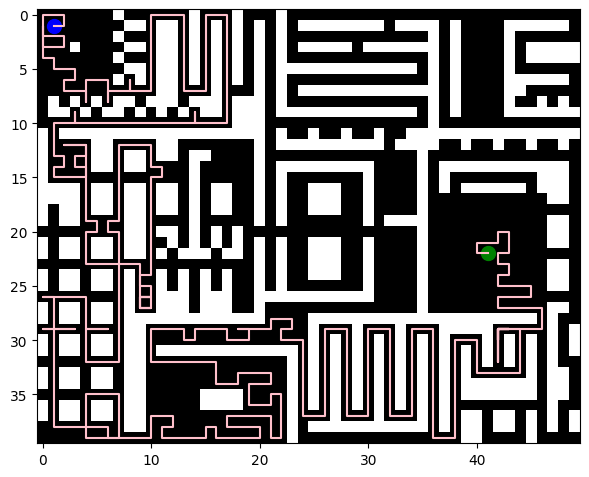

In [174]:
from PathSpecification import PathSpecification
from TSPData import TSPData
from VisualizerHelpers import Maze
from Visualizer import Visualizer

# Initializing the maze
maze = Maze.create_maze("./../data/medium_maze.txt")

spec = PathSpecification.read_coordinates("./../data/medium_coordinates.txt")

# Visualizing the path
Visualizer.visualize_individual_path(maze, shortest_route, spec)

<div style="background-color:#f1be3e">

_Put your extra code blocks above (if any) and write your answer here._

### 2.5 Parameter Optimization

#### Question 16

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 17

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

### 2.6 The Final Route

#### Question 18

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

### 2.7 Synthesis

#### Question 19

In [175]:
# Please keep your parameters for the synthesis part easily changeable here
gen = 1
no_gen = 1
q = 1000
evap = 0.1

persist_file = "./../tmp/my_tsp"
tsp_path = "./../data/tsp_products.txt"
coordinates = "./../data/hard_coordinates.txt"

# Construct optimization
maze = Maze.create_maze("./../data/hard_maze.txt")
tsp_data = TSPData.read_specification(coordinates, tsp_path)
aco = AntColonyOptimization(maze, gen, no_gen, q, evap)

# Run optimization and write to file
tsp_data.calculate_routes(aco)
tsp_data.write_to_file(persist_file)

# Read from file and print
tsp_data2 = TSPData.read_from_file(persist_file)
print(tsp_data == tsp_data2)

# Solve TSP using your own paths file
ga = GeneticAlgorithm(generations, population_size)
solution = ga.solve_tsp(tsp_data2)
tsp_data2.write_action_file(solution, "./../data/tsp_solution.txt")

Ready reading maze file ./../data/hard_maze.txt


TypeError: AntColonyOptimization.__init__() missing 1 required positional argument: 'intelligent'

<div style="background-color:#f1be3e">

_Put your extra code blocks above (if any) and write your answer here._

## Part 3: Open Questions
### 3.1 Reflection

#### Question 20

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 21

<div style="background-color:#f1be3e">

_Write your answer here._

### 3.2 Pen and Paper

#### Question 22

- We should maximazie nutritional value, and minimize the price. 
- There are 2 pareto frontiers the first at nutritional value 9 and price 3 and the second at nutritional value 6 and price 1. All other points are dominated by these 2 pareto frontiers. 
- The four products taken by the robot would be 2 pareto frontiers I gave before and then the most extreme points from the rest of the points that are dominating the rest so in our case nutritional value 8 price 7 and nutritional value 1 and price 1. (so if nutritional value is y and price is x the points are (3,9), (1,6), (7,8), (1,1))

### 3.3 Division of Work

#### Question 23




|          Component          |  Jacek Obiała   |  Michał Szelejewski   |  Marcin Łysikowski   |  Adam Porat   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     25\%     |     25\%     |     25\%     |     25\%     |
| Code (implementation)       |     25\%     |     25\%     |     25\%     |     25\%     |
| Code (validation)           |     25\%     |     25\%     |     25\%     |     25\%     |
| Experiments (execution)     |     25\%     |     25\%     |     25\%     |     25\%     |
| Experiments (analysis)      |     25\%     |     25\%     |     25\%     |     25\%     |
| Experiments (visualization) |     25\%     |     25\%     |     25\%     |     25\%     |
| Report (original draft)     |     25\%     |     25\%     |     25\%     |     25\%     |
| Report (reviewing, editing) |     25\%     |     25\%     |     25\%     |     25\%     |

### References

Used for question 1: https://www.geeksforgeeks.org/dsa/travelling-salesman-problem-using-dynamic-programming/

# AI use

Used LLM's to check the spelling and grammar.